# Option market-making and vol arbitrage 

`src/option_market_making` implements the baseline single-option model of
**Lucic & Tse (2025)**, *"Option market-making and vol arbitrage"* (Risk.net).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../src/vol_surface'))

import json, warnings
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from option_market_making import bs_mm, riccati
from option_market_making.edge import phi_edge
from option_market_making.psi1 import flow_corrections, psi1
from option_market_making.quoting import MMParams, optimal_spreads
from option_market_making.pde import solve_hjb_pde
from option_market_making.sim import objective, objective_summary, simulate

%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#dcdcd8'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GRID, 'axes.labelcolor': MUTED,
    'axes.titlecolor': INK, 'axes.titlesize': 11, 'axes.titleweight': 'semibold',
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'grid.color': GRID, 'grid.linewidth': 0.6,
    'legend.frameon': False, 'lines.linewidth': 2.0,
})

## 1. The surface and the contract

The market-implied vol comes from the calibrated **Global eSSVI** surface in `vol_surface`.
This notebook replays the frozen Deribit snapshot the test-suite uses, so every number below is
reproducible; flip `USE_LIVE = True` to recalibrate against the live chain instead.

In [2]:
USE_LIVE = True   # True re-pulls Deribit and recalibrates (needs network)

from vol_surface.global_essvi import ESSVISlice, GlobalESSVISurface

SNAPSHOT = '../tests/option_market_making/deribit_snapshot.json'

if USE_LIVE:
    from vol_surface import global_essvi as ge
    chain = ge.fetch_quotes(currency='BTC', max_T=1.5)
    surface = ge.calibrate(**ge.chain_to_calibration_inputs(chain)).surface
    tau = min(surface.maturities, key=lambda t: abs(t - 30 / 365))
    S0 = float(surface.forward_at(tau))
    K = round(S0, -3)
else:
    snap = json.load(open(SNAPSHOT))
    surface = GlobalESSVISurface(
        snap['maturities'], [ESSVISlice(**s) for s in snap['slices']], snap['forwards'],
    )
    S0, K, tau = snap['spot'], snap['strike'], snap['tau']

IV = bs_mm.sigma_imp(surface, K, tau)
O_0 = bs_mm.call_price(S0, K, tau, IV)

print(f"spot        S0    = {S0:,.0f}")
print(f"strike      K     = {K:,.0f}   ({K / S0 - 1:+.2%} moneyness)")
print(f"expiry      tau   = {tau:.4f} yr  ({tau * 365:.0f} calendar days)")
print(f"implied vol       = {IV:.2%}")
print(f"call mark   O(0)  = {O_0:,.0f}   ({O_0 / S0:.2%} of spot)")

spot        S0    = 79,252
strike      K     = 79,000   (-0.32% moneyness)
expiry      tau   = 0.0480 yr  (18 calendar days)
implied vol       = 36.27%
call mark   O(0)  = 2,637   (3.33% of spot)


## 2. Parameters

Maker's view of volatility $\sigma$, the arrival
intensities $\lambda_0^i$ and the decays $\kappa^i$ for $i\in \{a,b\}$ are inputs. 

| Parameter | Value |
| --- | --- |
| $1/\kappa^b,\ 1/\kappa^a$ | $40, $33 |
| $\lambda_0^b,\ \lambda_0^a$ | 100/day/side, bid 15% heavier |
| $\alpha,\ \beta$ | 2, 4357 |
| $\sigma$ | implied vol + 5 vol pts |
| $T$ | 0.5/252 |

Given maturity $\tau$ and strike price $K$, the maker thinks realised will beat implied — they want to be **long** vol, with half a trading day $T$. 
Market-making takes place over a time interval $[0,T]$, with $T\in (0,\tau).$

The optimal bid/ask half-spreads (eq. 11) are:

$$\delta^{b,*}(t,s,q) = \underbrace{\frac{1}{\kappa^b}}_{\text{liquidity}} \;-\; \underbrace{\psi_1(t,s)}_{\text{vol-arb edge + order-flow}} \;-\; \underbrace{(2q+1)\,\psi_2(t)}_{\text{inventory}}$$

$$\delta^{a,*}(t,s,q) = \underbrace{\frac{1}{\kappa^a}}_{\text{liquidity}} \;+\; \underbrace{\psi_1(t,s)}_{\text{vol-arb edge + order-flow}} \;+\; \underbrace{(2q-1)\,\psi_2(t)}_{\text{inventory}}$$

with $\kappa^b,\kappa^a$ the bid/ask intensity decays, and $q$ the market
maker's current inventory in holdings ($q>0$ = long the option, $q<0$ = short).

$\psi_1(t,s)$ splits into eq. 9's three terms — the vol-arb edge, plus two **order-flow
correction** terms that exist only because the bid and ask sides of the book are not symmetric:

$$\psi_1(t,s) = \underbrace{\varphi(t,s)}_{\text{vol-arb edge}} \;+\; \underbrace{2e^{-1}\,(\lambda_0^b - \lambda_0^a) \int_t^T D(t,u)\,\psi_2(u)\,du}_{\text{order-flow correction, linear}} \;+\; \underbrace{2e^{-1}\,(\lambda_0^b\kappa^b - \lambda_0^a\kappa^a) \int_t^T D(t,u)\,\psi_2(u)^2\,du}_{\text{order-flow correction, quadratic}}$$

where
$\lambda_0^b - \lambda_0^a$ and $\lambda_0^b\kappa^b - \lambda_0^a\kappa^a$
are the bid/ask imbalance in base fill intensity and in fill elasticity. Note that both are zero for a
symmetric book ($\lambda_0^b=\lambda_0^a,\ \kappa^b=\kappa^a$), in which case the order-flow
correction vanishes and $\psi_1 = \varphi$.

$D(t,u)$ and $\psi_2(u)$ are section §3's objects; the edge term $\varphi(t,s)$ (eq. 10) is

$$\varphi(t,s) = \frac{K(\sigma^2-\sigma_{\text{imp}}^2)}{2} \int_t^T \frac{D(t,u)}{\sqrt{\sigma_{\text{imp}}^2(\tau-u)+\sigma^2(u-t)}}\, \phi\bigg(\frac{\ln(s/K) - \tfrac12\sigma^2(u-t) - \tfrac12\sigma_{\text{imp}}^2(\tau-u)}{\sqrt{\sigma_{\text{imp}}^2(\tau-u)+\sigma^2(u-t)}} \bigg)\, du,
$$

with $\phi(\cdot)$ the standard normal density, $\sigma$ the market maker's own vol view, and
$\sigma_{\text{imp}}$ the market's implied vol. **Only $\varphi$ carries spot price dependence** — the order-flow
correction is a function of $t$ alone, never of $s$, $K$, or $\tau$.

The code cell below evaluates every term at $t=0,\ s=S_0,\ q=0$.

In [3]:
PARAMS = MMParams(
    alpha=2.0, beta=4357.0,
    lambda0_b=252 * 100 * 1.15, lambda0_a=252 * 100.0,
    kappa_b=0.025, kappa_a=0.030,
    sigma=IV + 0.05,
)
T = 0.5 / 252

Q0 = 0.0   # inventory level this decomposition is evaluated at

edge_0 = phi_edge(0.0, S0, K, tau, T, IV, PARAMS)
flow_0 = flow_corrections(0.0, T, PARAMS)
psi2_0 = riccati.psi2(0.0, T, PARAMS)
db_0, da_0 = optimal_spreads(0.0, S0, Q0, K, tau, T, IV, PARAMS)

anatomy = pd.DataFrame({
    'component':    ['liquidity', 'vol-arb edge', 'order-flow correction', 'inventory', 'TOTAL half-spread'],
    'bid formula':  ['1/\u03ba\u1d47', '\u2212\u03c6(t,s)', '\u2212[\u03c8\u2081\u2212\u03c6]',
                     '\u2212(2q+1)\u03c8\u2082(t)', '\u03b4\u1d47,*(t,s,q)'],
    'bid ($)':      [1 / PARAMS.kappa_b, -edge_0, -flow_0, -(2 * Q0 + 1) * psi2_0, db_0],
    'ask formula':  ['1/\u03ba\u1d43', '+\u03c6(t,s)', '+[\u03c8\u2081\u2212\u03c6]',
                     '+(2q\u22121)\u03c8\u2082(t)', '\u03b4\u1d43,*(t,s,q)'],
    'ask ($)':      [1 / PARAMS.kappa_a, edge_0, flow_0, (2 * Q0 - 1) * psi2_0, da_0],
})
anatomy['share of bid'] = (anatomy['bid ($)'].abs() / db_0).map('{:.1%}'.format)
display(anatomy)
print(f"\nquoted width = {db_0 + da_0:,.2f}  ({(db_0 + da_0) / O_0 * 1e4:.0f} bp of the option mark)")


,component,bid formula,bid ($),ask formula,ask ($),share of bid
0,liquidity,1/κᵇ,40.000,1/κᵃ,33.333,97.4%
1,vol-arb edge,"−φ(t,s)",-3.477,"+φ(t,s)",3.477,8.5%
2,order-flow correction,−[ψ₁−φ],2.561,+[ψ₁−φ],-2.561,6.2%
3,inventory,−(2q+1)ψ₂(t),2.000,+(2q−1)ψ₂(t),2.000,4.9%
4,TOTAL half-spread,"δᵇ,*(t,s,q)",41.085,"δᵃ,*(t,s,q)",36.248,100.0%



quoted width = 77.33  (293 bp of the option mark)


**Comment 1:** At a 5-vol-point view the vol-arb edge is $\varphi = +\$2.62$, **6.2% of the bid spread** —
and the order-flow correction comes in at $-\$2.56$, so the two nearly cancels out:
$\psi_1 = \varphi + \text{flow} = +\$0.05$. The vol-arbitrage term $\psi_1$ contributes almost nothing at these parameters. The liquidity term $1/\kappa^b$ accounts for most of the bid spread at 95.4%.

## 3. The inventory weight $\psi_2$ and the discount kernel $D(t,u)$

§2's optimal spreads (eq. 11), recalled here:

$$\delta^{b,*}(t,s,q) = \frac{1}{\kappa^b} - \psi_1(t,s) - (2q+1)\,\psi_2(t)
\qquad
\delta^{a,*}(t,s,q) = \frac{1}{\kappa^a} + \psi_1(t,s) + (2q-1)\,\psi_2(t)$$
The inventory weight $\psi_2(t) <0$ always, accounts for:
$$\psi_2(t) = \sqrt{\varUpsilon\beta}\frac{\zeta_- e^{-\eta(T-t)} - \zeta_+ e^{\eta(T-t)}}{\zeta_- e^{-\eta(T-t)} + \zeta_+ e^{\eta(T-t)}} $$
where
$$\varUpsilon := \frac{1}{2e^{-1}(\lambda_0^{\mathrm{a}}\kappa^{\mathrm{a}} + \lambda_0^{\mathrm{b}}\kappa^{\mathrm{b}})}, \quad \eta := \sqrt{\frac{\beta}{\varUpsilon}}, \quad \zeta_{\pm} := \sqrt{\varUpsilon\beta} \pm \alpha
$$

$\psi_2(t)$ is the coefficient multiplying the inventory adjustment $(2q\pm1)$ on each side.It depends only on $\alpha,\beta$ and the
flow parameters $\lambda_0,\kappa$: never on the spot $s$, strike $K$, or maturity $\tau$.

The discount term:
$$D(t, u) := \frac{\zeta_- e^{-\eta(T-u)} + \zeta_+ e^{\eta(T-u)}}{\zeta_- e^{-\eta(T-t)} + \zeta_+ e^{\eta(T-t)}}$$

$D(t,u)$ discounts edge earned at a future time $u$ back to $t$ *inside*
$\psi_1$'s construction — but its decay rate is exactly what caps how far ahead $\psi_1$ edge term can
exploit (see §4). Both are shown across three values of $\beta$, because at the baseline $\psi_2$ alone is a flat
line.

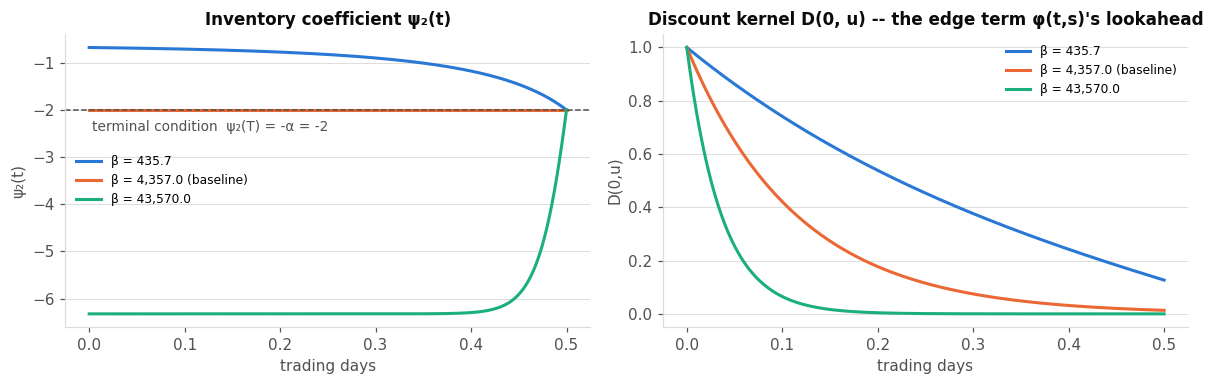

,β,√(Υβ),"D(0, T)"
0,435.700,0.632,0.127
1,"4,357.000",2.000,0.013
2,"43,570.000",6.324,0.000


In [4]:
t_grid = np.linspace(0.0, T, 200)
ups = riccati.upsilon(PARAMS.lambda0_b, PARAMS.kappa_b, PARAMS.lambda0_a, PARAMS.kappa_a)

# Both panels are shown across beta. At the baseline alone psi2 is a flat line 
betas = [435.7, PARAMS.beta, 43570.0]
labels = [f'β = {b:,.1f}' + (' (baseline)' if b == PARAMS.beta else '') for b in betas]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for color, b, label in zip(SERIES, betas, labels):
    p_b = replace(PARAMS, beta=b)
    axes[0].plot(t_grid * 252, [riccati.psi2(float(t), T, p_b) for t in t_grid],
                 color=color, label=label)
    axes[1].plot(t_grid * 252, [riccati.discount_kernel(0.0, float(u), T, p_b) for u in t_grid],
                 color=color, label=label)

axes[0].axhline(-PARAMS.alpha, color=MUTED, lw=1, ls='--')
axes[0].annotate(f'terminal condition  \u03c8\u2082(T) = -α = {-PARAMS.alpha:g}',
                 xy=(0, -PARAMS.alpha), xytext=(2, -14), textcoords='offset points',
                 color=MUTED, fontsize=9)
axes[0].set_title('Inventory coefficient \u03c8\u2082(t)')
axes[0].set_xlabel('trading days'); axes[0].set_ylabel('\u03c8\u2082(t)')

axes[1].set_title('Discount kernel D(0, u) -- the edge term \u03c6(t,s)\'s lookahead')
axes[1].set_xlabel('trading days'); axes[1].set_ylabel('D(0,u)')

for ax in axes:
    ax.legend(fontsize=8); ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

lookahead = pd.DataFrame([
    {'β': b,
     '√(Υβ)': np.sqrt(ups * b),
     'D(0, T)': riccati.discount_kernel(0.0, T, T, replace(PARAMS, beta=b))}
    for b in (435.7, 4357.0, 43570.0)
])

display(lookahead)

$\psi_2(t)$ is how hard we lean on our quote for every unit of inventory we're
carrying. It shows up in the spread as $(2q\pm1)\psi_2(t)$ — the bigger $|\psi_2(t)|$ is, the harder
we react to carrying a position.

It comes from one ODE equation, which is solved backward, not forward:

$$\psi_2'(t) + \frac{\psi_2(t)^2}{\Upsilon} = \beta, \qquad \psi_2(T) = -\alpha$$

The second part says whatever $\beta$ is, $\psi_2$ **must** equal exactly $-\alpha$
at the close of trading ($t=T$). The equilibrium of this backward ODE is solved to be $-\sqrt{\Upsilon\beta}$.

Comparing $-\sqrt{\Upsilon\beta}$ to $-\alpha$ tells:

- **Equal:** $-\sqrt{\Upsilon\beta} = -\alpha$ (true for $\beta=4357$, since $\sqrt{\Upsilon\cdot4357}=2=\alpha$).
  The target and the fixed end-of-day value are the same: $\psi_2(t) = -\alpha \forall t\in[0,T]$. That's the flat orange line.
- **Bigger $\beta$**: $\sqrt{\Upsilon\beta} > \alpha \iff -\sqrt{\Upsilon\beta} < -\alpha$. That's the
  green line ($\beta=43{,}570$).
- **Smaller $\beta$**: $\sqrt{\Upsilon\beta} < \alpha\iff -\sqrt{\Upsilon\beta} > -\alpha$. That's
  the blue line ($\beta=436.7$).

**In every case the trajectory is**: start near the equilibrium $-\sqrt{\Upsilon\beta}$, end at the terminal condition $-\alpha$. The ODE is solved backward (terminal condition is the boundary), but the trading day runs forward.
So: small $\beta$ → curve goes **down**;
big $\beta$ → curve goes **up**; the exactly-matched $\beta$ → flat. 

**Practically**: in the first case ($\zeta_- > 0$, large $\beta$), the model gets aggressive about managing inventory early in the day and relaxes toward the close. In the second case ($\zeta_- < 0$, small $\beta$), it's relaxed early and tightens up as the close approaches. At the constant-edge ($\zeta_- = 0$), it doesn't change at all — constant reaction throughout.

---

$D(t,u)$ answers: *a dollar of profit at some future moment $u$ — how much
is that worth right now, at time $t$?* It equals $1$ at $u=t$ (a dollar today is worth a dollar
today) and shrinks the further away $u$ is — future money gets discounted.

How fast it shrinks is set by $\eta= \sqrt{\beta/\Upsilon}$. When $\zeta_- \neq 0$, for $u$ far enough before $T$ (specifically, $\eta(T-u)$ large), the $\zeta_+ e^{\eta(T-u)}$ term dominates $\zeta_- e^{-\eta(T-u)}$ in the numerator (because the growing exponential overwhelms the decaying one), and similarly in the denominator. So the $\zeta_-$ terms become negligible, and we recover an approximation.

$$D(t,u) \approx e^{-\eta(u-t)}$$

When $\zeta_- = 0$, we have equality. $\eta$ is how fast $D(t,u) $ falls off, measured in 
$e$-foldings per year. Larger $\eta$ means faster rate.

Bigger $\eta$ means faster decrease rate, means a shorter span for future profit. On the right-hand
chart, the green line (same big-$\beta$ case) crashes to near zero almost immediately — it barely looks
past the next few minutes. The blue line (small $\beta$) fades much more slowly, still caring about
profit half a day out.


The **$e$-folding time** ($1/\eta$) is simply the amount of future time it takes for a signal's importance to drop to about $36.8\%$ of its original value.
If we look into the future by setting $u - t = 1/\eta$, the math simplifies:

$$D(t, u) = e^{-\eta\left(\frac{1}{\eta}\right)} = e^{-1} \approx 0.368$$


Because the decay is exponential, multiplying $1/\eta$ dramatically suppresses future information:

* **At $u - t = 1/\eta$:** $D(t,u) = e^{-1} \approx 0.368$ (36.8% influence remains)
* **At $u - t = 3/\eta$:** $D(t,u) = e^{-3} \approx 0.050$ (5% influence remains)
* **At $u - t = 5/\eta$:** $D(t,u) = e^{-5} \approx 0.007$ (less than 1% influence remains)

Therefore, in a general integral like:

$$\int_t^T D(t, u) (\dots) \, du \approx \int_t^{O(1/\eta)} D(t, u) (\dots) \, du $$

the factor $D(t, u)$ acts like a diminishing term for $1/\eta \ll (T-t)$. By the time $u - t$ reaches $3/\eta$, over $95\%$ of the weight is gone. By $5/\eta$, over $99\%$ is gone.

**Because anything beyond $u - t = 3/\eta$ is multiplied by near-zero numbers, events past that point have virtually no impact on the calculation at time $t$. We can safely ignore the rest of the timeline up to $T$.**


---

**The running inventory penalty $\beta$ serves a dual purpose in the model. Beyond its direct role in penalizing variance $\int_0^T Q_u^2 \, du$, $\beta$ caps the lookahead horizon of the volatility-arbitrage edge term $\varphi(t, s)$.**

Increase $\beta$ (we hate inventory more) $\Rightarrow \eta= \sqrt{\beta/\Upsilon}$ increases $\Rightarrow 1/\eta$ decreases $\Rightarrow D(t,u)$ decays faster $\Rightarrow \varphi(t,s)$ only integrates vol-arb profit over a shorter future window $\Rightarrow$ the edge term that shifts our quotes is smaller, because it's discounting away profit we could have harvested over a longer horizon.

Decrease $\beta$ (we're relaxed about inventory) $\Rightarrow \eta= \sqrt{\beta/\Upsilon}$  decreases $\Rightarrow 1/\eta$ increases $\Rightarrow D(t,u)$ decays slower $\Rightarrow \varphi(t,s)$ looks further ahead $\Rightarrow$ bigger edge term, because we're valuing profit we'll collect over a longer window.

## 4. When does the maker's vol view actually move the quote?

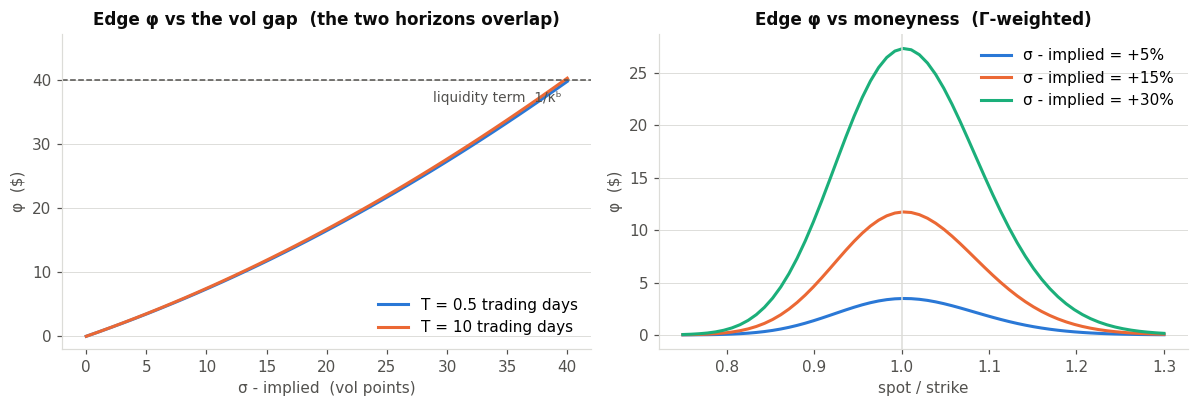

,σ - implied (vol pts),φ ($),as % of 1/κᵇ
0,5,3.477,9%
1,10,7.390,18%
2,20,16.515,41%
3,30,27.338,68%
4,40,39.821,100%


In [5]:
gaps = np.linspace(0.0, 0.40, 40)
horizons_d = [0.5, 10.0]
edge_by_gap = {
    f'T = {d:g} trading days': np.array([
        phi_edge(0.0, S0, K, tau, d / 252, IV, replace(PARAMS, sigma=IV + g)) for g in gaps
    ]) for d in horizons_d
}

moneyness = np.linspace(0.75, 1.30, 60)
edge_by_spot = {
    f'σ - implied = {g:+.0%}': np.array([
        phi_edge(0.0, float(K * m), K, tau, T, IV, replace(PARAMS, sigma=IV + g)) for m in moneyness
    ]) for g in (0.05, 0.15, 0.30)
}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for color, (label, values) in zip(SERIES, edge_by_gap.items()):
    axes[0].plot(gaps * 100, values, color=color, label=label)
axes[0].axhline(1 / PARAMS.kappa_b, color=MUTED, lw=1, ls='--')
axes[0].annotate('liquidity term  1/κᵇ', xy=(gaps[-1] * 100, 1 / PARAMS.kappa_b),
                 xytext=(-4, -14), textcoords='offset points', ha='right',
                 color=MUTED, fontsize=9)
axes[0].set_ylim(top=1 / PARAMS.kappa_b * 1.18)
axes[0].set_title('Edge φ vs the vol gap  (the two horizons overlap)')
axes[0].set_xlabel('σ - implied  (vol points)'); axes[0].set_ylabel('φ  ($)')
axes[0].legend(loc='lower right')   # keeps the legend off the 1/κᵇ reference line

for color, (label, values) in zip(SERIES, edge_by_spot.items()):
    axes[1].plot(moneyness, values, color=color, label=label)
axes[1].axvline(1.0, color=GRID, lw=1)
axes[1].set_title('Edge φ vs moneyness  (Γ-weighted)')
axes[1].set_xlabel('spot / strike'); axes[1].set_ylabel('φ  ($)')
axes[1].legend(loc='upper right')

for ax in axes:
    ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

display(pd.DataFrame({
    'σ - implied (vol pts)': [5, 10, 20, 30, 40],
    'φ ($)': [phi_edge(0.0, S0, K, tau, T, IV, replace(PARAMS, sigma=IV + g / 100))
              for g in (5, 10, 20, 30, 40)],
}).assign(**{'as % of 1/κᵇ': lambda d: (d['φ ($)'] / (1 / PARAMS.kappa_b)).map('{:.0%}'.format)}))

**Left chart — $\varphi$ vs. how wrong we think the market is.** The x-axis is our guess minus the
market's implied vol, in vol points; the y-axis is the vol-arb edge, $\varphi$. It goes up: the more
we disagree, the more we can make.

 The two colored lines are a
half-day trading window and a 10-day one, and **they sit almost on top of each other**. This is §3's lookahead result again: the model only "looks ahead" about the interval $[t,t+O(1/\eta)]$ before
it stops caring, so a 10-day window buys nothing extra over a half-day one.

The dashed line at the top ($40) is $1/\kappa^b$ — the plain liquidity charge, with no vol opinion at
all. The curve stays well below it even at a 40-point disagreement.

It means our opinion about volatility barely matters to the price we quote — the price is set almost entirely by other stuff, no matter how right we think we are.
Even our most aggressive volatility opinion never gets to add more than our ordinary liquidity charge does by default. **Our quote is always dominated by "how risky is it to quote a price" not by "how right do I think I am about volatility."**

---

**Right chart — $\varphi$ vs. spot price (moneyness).** All three curves peak right ATM and fall away on
both sides. Because the edge only exists because we are delta-hedging, and how much we have to keep
re-adjusting that hedge as price changes is gamma. **The edge is largest exactly ATM and fades toward zero for options deep ITM or OTM.** So even a strong vol opinion is
close to worthless on an option far from the money.

## 5. The inventory skew

Fact 1: The slope in `q` is exactly `2ψ₂`


$$\delta^{b,*} = \frac{1}{\kappa^b} - \psi_1(t,s) - (2q+1)\psi_2(t) = \underbrace{\Big[\tfrac{1}{\kappa^b}-\psi_1(t,s) -\psi_2(t) \Big]}_{\text{constant in }q} \;-\; 2\psi_2(t)\cdot q$$

which is eq. 11. Written as a function of `q` alone, everything except `q` is a constant. 
**The slope in `q` is `−2ψ₂(t)` — for any `α, β, λ, κ`, at any `t`.** Do the same for the ask side (using `q-1` instead of `q+1`) and we get slope `+2ψ₂(t)`.

Fact 2: The total width

Add the two optimal bid/ask:

$$\delta^{b,*}+\delta^{a,*} = \Big(\tfrac{1}{\kappa^b}-\psi_1(t,s)-(2q+1)\psi_2(t)\Big) + \Big(\tfrac{1}{\kappa^a}+\psi_1(t,s)+(2q-1)\psi_2(t)\Big)= \frac{1}{\kappa^b}+\frac{1}{\kappa^a} - 2\psi_2(t)$$

**General formula, holds for any parameters.** 


This formula says the width is constant in `q`. But it still has a `t` sitting in it, through `ψ₂(t)`. At *our* baseline, `ψ₂(t) ≡ −2` for every `t`, so the width is $77.33 the whole trading day, not just at every `q`.

**Away from the baseline,** if `ψ₂(t)` varies rather than being a constant, the width would still be flat across `q` at any given instant, but it would drift over the course of the day.

In [6]:
q_grid = np.arange(-10, 11)
spreads = np.array([optimal_spreads(0.0, S0, float(q), K, tau, T, IV, PARAMS) for q in q_grid])

display(pd.DataFrame({
    'q': q_grid[::5], 'delta_b* ($)': spreads[::5, 0], 'delta_a* ($)': spreads[::5, 1], 'total width ($)': spreads[::5, 0] + spreads[::5, 1],
    'skew b-a ($)': spreads[::5, 0] - spreads[::5, 1],
}))

,q,delta_b* ($),delta_a* ($),total width ($),skew b-a ($)
0,-10,1.086,76.248,77.333,-75.162
1,-5,21.085,56.248,77.333,-35.163
2,0,41.085,36.248,77.333,4.836
3,5,61.084,16.249,77.333,44.836
4,10,81.084,-3.751,77.333,84.835


**1. The two sides move in opposite directions.** As we get more long ($q$ rising), our
bid keeps climbing (we are less willing to buy) while our
ask keeps falling (we are more willing to sell). The model is
actively trying to get rid of a position it does not want: make it cheap for people to buy from us,
expensive for people to sell to us. 

**2. At $q=+10$ the ask goes negative** ($-\$4.61$): the model would sell the option for *less* than
its theoretical fair value. Saying it would rather take a small guaranteed loss right now than
keep carrying this position — 
because holding the inventory is worse than eating the loss.

## 6. Benchmarks against a fixed-width quoter

Benchmarks against makers who quote a fixed width regardless of state, so both run through on **identical spot paths**. 

The scoring rule matters here. Eq. 11 does not maximise mean $V_T$; it maximises the paper's
objective (eq. 2)

$$\mathbb{E}\Big[\,V_T \;-\; \beta\!\int_0^T Q_u^2\,du \;-\; \alpha\,Q_T^2\,\Big]$$

**Test:** Benchmark the smart rule (eq. 11)
 against fixed-width quoters that never think about inventory or the vol view —
they just pick one fixed width and quote it all day. Three cases: half the plain liquidity width
($\times0.5$, tighter), the plain liquidity width with no adjustment ($\times1$), and double
($\times2$, wider).

Every strategy runs on the **exact same** simulated sequence of price moves — 
only the quoting rule differs. 

The bid-distance and ask-distance to theo are two plain numbers, unchanged into every step of the simulation —  never look at `t`, inventory `q`, or the spot `s`.

"fixed" means the *distance* from the mark is fixed, not the actual dollar price. The mark itself (the option's fair value) moves all day as the spot price moves, so the quoted bid/ask prices *do* move — they're just always sitting exactly `1/κᵇ` below and `1/κᵃ` above wherever the mark currently is, with zero adjustment for anything else. The `×1` case is exactly "quote what the optimal rule *would* quote if we deleted the vol-view term and pretended inventory was always zero" and never updated again.

In [7]:
N_PATHS, N_STEPS = 4000, 400
SIM = dict(S0=S0, n_steps=N_STEPS, n_paths=N_PATHS, seed=1)

runs = {'optimal (eq. 11)': simulate(surface, K, tau, T, PARAMS, **SIM)}
for w in (0.5, 1.0, 2.0):
    runs[f'fixed-width x{w:g}'] = simulate(
        surface, K, tau, T, PARAMS,
        constant_spreads=(w / PARAMS.kappa_b, w / PARAMS.kappa_a), **SIM,
    )

summary = pd.DataFrame([
    {'strategy': name,
     'mean V_T': r.terminal_value.mean(),
     'sd V_T': r.terminal_value.std(),
     'mean / sd': r.terminal_value.mean() / r.terminal_value.std(),
     'fills / path': (r.n_bid_fills + r.n_ask_fills).mean(),
     'sd of q_T': r.q[:, -1].std(),
     'max |q|': np.abs(r.q).max()}
    for name, r in runs.items()
])
display(summary)

,strategy,mean V_T,sd V_T,mean / sd,fills / path,sd of q_T,max |q|
0,optimal (eq. 11),"1,421.558",338.987,4.194,38.428,2.156,10.000
1,fixed-width x0.5,"1,237.341",361.863,3.419,65.273,7.814,39.000
2,fixed-width x1,"1,476.916",357.793,4.128,39.438,6.334,27.000
3,fixed-width x2,"1,083.118",327.783,3.304,14.588,3.803,16.000


In [8]:
assert all(np.array_equal(runs['optimal (eq. 11)'].S, r.S) for r in runs.values()), \
    'paired comparison requires identical spot paths'

print('Eq. 2 -- the quantity eq. 11 actually maximises:')
display(objective_summary(runs, PARAMS))

base = objective(runs['optimal (eq. 11)'], PARAMS)
paired = pd.DataFrame([
    {'vs': name,
     'objective gap': (d := base - objective(r, PARAMS)).mean(),
     '95% CI': 1.96 * d.std() / np.sqrt(N_PATHS),
     't-stat': d.mean() / (d.std() / np.sqrt(N_PATHS)),
     'optimal wins on': f'{100 * (d > 0).mean():.1f}% of paths'}
    for name, r in runs.items() if not name.startswith('optimal')
])
display(paired)

Eq. 2 -- the quantity eq. 11 actually maximises:


,strategy,mean V_T,running penalty/fee,terminal penalty/fee,OBJECTIVE (value after fees),objective sd
0,optimal (eq. 11),"1,421.558",38.363,10.487,"1,372.707",335.017
1,fixed-width x0.5,"1,237.341",323.978,161.357,752.006,607.818
2,fixed-width x1,"1,476.916",194.484,95.190,"1,187.243",449.472
3,fixed-width x2,"1,083.118",63.830,31.003,988.285,315.727


,vs,objective gap,95% CI,t-stat,optimal wins on
0,fixed-width x0.5,620.701,21.671,56.137,82.5% of paths
1,fixed-width x1,185.465,17.267,21.053,61.9% of paths
2,fixed-width x2,384.422,14.122,53.352,80.0% of paths


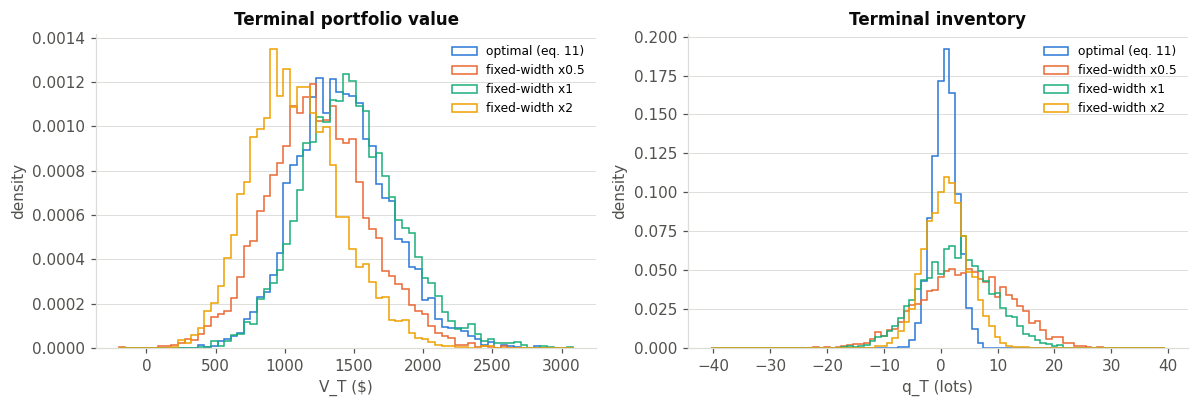

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.linspace(min(r.terminal_value.min() for r in runs.values()),
                   max(r.terminal_value.max() for r in runs.values()), 70)
for color, (name, r) in zip(SERIES, runs.items()):
    axes[0].hist(r.terminal_value, bins=bins, histtype='step', density=True, color=color, label=name)
    axes[1].hist(r.q[:, -1], bins=np.arange(-40, 41) - 0.5, histtype='step', density=True,
                 color=color, label=name)
axes[0].set_title('Terminal portfolio value'); axes[0].set_xlabel('V_T ($)'); axes[0].set_ylabel('density')
axes[1].set_title('Terminal inventory'); axes[1].set_xlabel('q_T (lots)'); axes[1].set_ylabel('density')
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()



**Comment:** At plain profit ($V_T$):
the fixed-width quoter at $1\times$ the model's own $1/\kappa^i \text{ for } i=b,a$, **makes more money on average**
than the optimal rule (\$1,472 vs \$1,431). It never widens for inventory, so it never turns away a
trade, it just keeps collecting spread non-stop, while the optimal rule
deliberately makes its own quote less attractive whenever it is carrying a position (§5), which
sometimes means missing a fill it would have been happy to take.

The left-hand histogram shows exactly this: the green "$\times1$" curve for terminal portfolio value
sits slightly shifted to the right of the blue "optimal" curve. On raw dollars, the fixed width wins.

But the model
was built to maximise eq. 2, profit *minus* a fee for carrying inventory the whole time. So on the right histogram, the $\times1$ quoter earned \$41 more raw profit than optimal, but paid \$289 in fees for it, against
optimal's \$47 — so optimal finishes **\$202 ahead** once the actual cost of the risk taken is
counted in Objective instead of plain $V_T$.



## 7. Realized vs Maker's vol edge



Earlier sections assumed the maker's opinion about
volatility is *correct*. This section lets belief and reality disagree. `realised_sigma` splits one
number into two: what the maker believes — which sets every quote they post — and what the
spot actually does, which drives the simulation. Before this they were forced to match.

**The test:** two trading windows (half a day vs ten days) crossed with two levels of beliefs (the
maker thinks vol will be 5 points above the implied vol vs 20 points above it) — four
combinations in total.

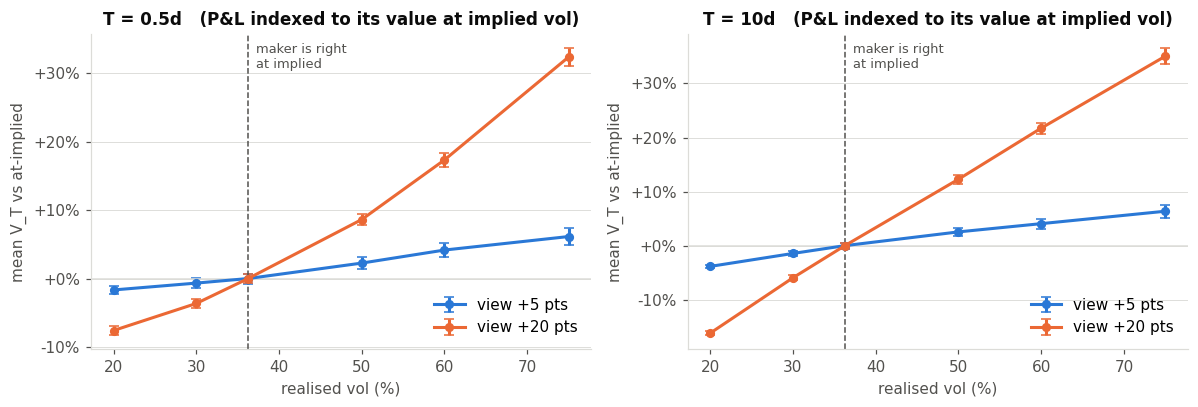

,case,mean V_T at implied,mean OBJECTIVE at implied,V_T range (20%-75% vol),range as % of P&L,range as % of OBJECTIVE,mean |q| (lots)
0,"0.5d, view +5 pts","1,421.570","1,372.683",110.852,7.8%,8.1%,1.619
1,"0.5d, view +20 pts","1,415.115","1,284.509",565.014,39.9%,44.0%,2.953
2,"10d, view +5 pts","28,345.899","27,346.679","2,893.234",10.2%,10.6%,1.872
3,"10d, view +20 pts","28,233.730","23,973.234","14,462.944",51.2%,60.3%,4.099


In [10]:
realised = np.array([0.20, 0.30, IV, 0.50, 0.60, 0.75])

# Mean V_T as a function of the vol the spot ACTUALLY realises, holding the
# maker's belief -- and therefore every quote they post -- fixed at IV + gap.
def sweep(horizon_days, believed_gap, n_paths=3000, steps=600, seed=6):
    p = replace(PARAMS, sigma=IV + believed_gap)
    rows = []
    for rs in realised:
        r = simulate(surface, K, tau, horizon_days / 252, p, S0=S0, n_steps=steps,
                     n_paths=n_paths, seed=seed, realised_sigma=float(rs))
        rows.append({'realised vol': rs, 'mean V_T': r.terminal_value.mean(),
                     '95% CI': 1.96 * r.terminal_value.std() / np.sqrt(n_paths),
                     'mean |q|': np.abs(r.q).mean(),
                     'mean OBJECTIVE': objective(r, p).mean()})
    return pd.DataFrame(rows)

# Two horizons x two conviction levels. The second gap is the point: a view only
# pays if you skew hard enough on it to actually build a position.
cases = {
    '0.5d, view +5 pts':  sweep(0.5, 0.05),
    '0.5d, view +20 pts': sweep(0.5, 0.20),
    '10d, view +5 pts':   sweep(10.0, 0.05),
    '10d, view +20 pts':  sweep(10.0, 0.20),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for ax, horizon in zip(axes, ('0.5d', '10d')):
    subset = {k: v for k, v in cases.items() if k.startswith(horizon + ',')}
    for color, (label, df) in zip(SERIES, subset.items()):
        # Indexed to each case's own value at implied vol, so two conviction
        # levels with very different absolute P&L share one axis honestly.
        base = float(df.loc[np.isclose(df['realised vol'], IV), 'mean V_T'].iloc[0])
        ax.errorbar(df['realised vol'] * 100, df['mean V_T'] / base - 1,
                    yerr=df['95% CI'] / base, color=color, marker='o', ms=5,
                    capsize=3, label=label.split(', ')[1])
    ax.axvline(IV * 100, color=MUTED, lw=1, ls='--')
    ax.axhline(0, color=GRID, lw=1)
    ax.annotate('maker is right\nat implied', xy=(IV * 100, ax.get_ylim()[1]),
                xytext=(5, -22), textcoords='offset points', color=MUTED, fontsize=8.5)
    ax.set_title(f'T = {horizon}   (P&L indexed to its value at implied vol)')
    ax.set_xlabel('realised vol (%)'); ax.set_ylabel('mean V_T vs at-implied')
    ax.yaxis.set_major_formatter(lambda v, _: f'{v:+.0%}')
    ax.legend(); ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

sensitivity = pd.DataFrame([
    {'case': label,
     'mean V_T at implied': (base := float(df.loc[np.isclose(df['realised vol'], IV), 'mean V_T'].iloc[0])),
     'mean OBJECTIVE at implied': (base_obj := float(df.loc[np.isclose(df['realised vol'], IV), 'mean OBJECTIVE'].iloc[0])),
     'V_T range (20%-75% vol)': (rng := df['mean V_T'].max() - df['mean V_T'].min()),
     'range as % of P&L': f"{rng / base:.1%}",
     'range as % of OBJECTIVE': f"{rng / base_obj:.1%}",
     'mean |q| (lots)': df['mean |q|'].mean()}
    for label, df in cases.items()
])
display(sensitivity)


The x-axis is what happened (realized vol). The y-axis is profit,
*indexed*: shown as a \% difference from whatever the maker would have made had reality landed
exactly on the option market's own number, $\sigma_{\text{imp}}$ (the dashed line) — **not** the
maker's own bet, which by construction always sits 5 or 20 points above that line. 

**Comment:** 

- Compare colours *within* a panel first: **the bold view (+20 points) is a far steeper line than the mild view (+5 points)**.  Half a day, +5-point view: P&L moves **4.5%** across realised vol from 20% to 75%. The maker
  could be wrong by twenty vol points in either direction and barely notice. Ten days, same view: only **5.1%**. Ten times the horizon buys almost no extra vol exposure.
  
- Comparing the
*same* colour *across* the two panels (half a day vs ten days) — they are **nearly identical slopes**.
Twenty times the horizon barely changes how exposed the maker is to being wrong.


For the `mean |q|` column. Lengthening the horizon barely raise $|q|$,
because $\psi_2$ pushes back — the position never gets the
chance to build up bigger. **Only higher belief raises $|q|$**, by skewing the quote hard enough to
keep winning the side of the trade the maker wants.

Note that **both cases at a given horizon earn the same P&L and Objective *at* implied vol (Columns 2,3)**


=> P&L and Objective only depend on the beliefs not the horizon.


**Why the horizon barely moves `mean |q|`: `q` has its own restoring force, faster than either window.**

Fills happen at rates that depend on the current spread, which depends on `q` (`\lambda^b(q) = \lambda_0^b e^{-\kappa^b \delta^{b,*}(q)}`, and similarly for `\lambda^a`). Differentiating the net drift `\lambda^b(q)-\lambda^a(q)` with respect to `q` gives a genuine restoring-force strength:

$$\gamma := -\frac{d}{dq}\big[\lambda^b(q)-\lambda^a(q)\big] = 2|\psi_2|\big[\kappa^b\lambda^b(q) + \kappa^a\lambda^a(q)\big]$$

`1/\gamma` is how fast `q` itself snaps back toward its resting point — a different, much faster clock than `\psi_2`'s own relaxation from §3. Computed below and checked directly against the simulated path, not just asserted.

psi2(0)                     = -2.0000
gamma (q's restoring rate)  = 5,921.9 /yr
1/gamma                    = 0.0426 trading days
T=0.5d is 11.7x that relaxation time; T=10d is 235.0x


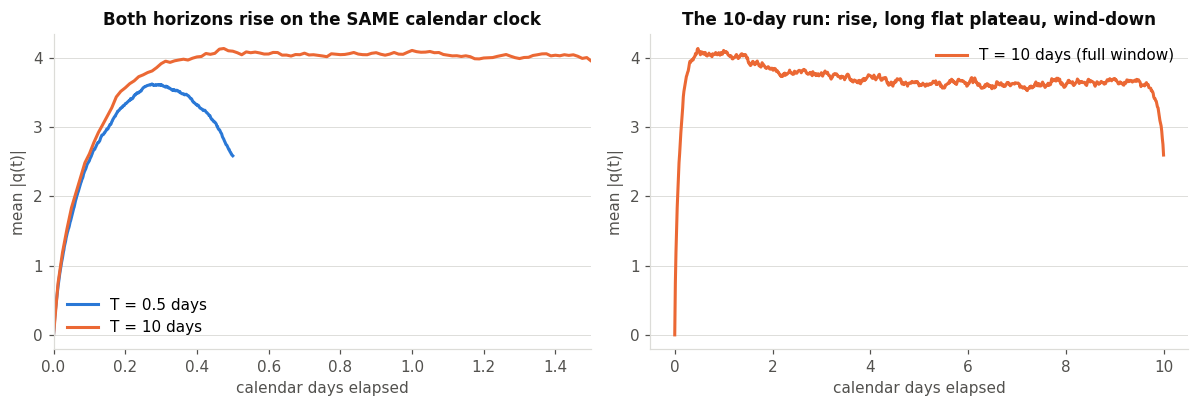

,horizon,peak mean |q|,day of peak,T / (1/gamma)
0,T = 0.5 days,3.623,0.275,11.750
1,T = 10 days,4.136,0.475,234.996


In [11]:
# q's OWN restoring-force timescale -- a different, much faster clock than
# psi2's own relaxation (Sec. 3). Fill rates lambda_b(q), lambda_a(q) depend on q
# through the spread, and differentiating lambda_b(q)-lambda_a(q) at q=0 gives
# the local restoring rate gamma := 2|psi2| * (kappa_b*lambda_b + kappa_a*lambda_a).
p_bold = replace(PARAMS, sigma=IV + 0.20)
psi2_now = riccati.psi2(0.0, 0.5 / 252, p_bold)
gamma_q = 2 * abs(psi2_now) * (p_bold.kappa_b * p_bold.lambda0_b + p_bold.kappa_a * p_bold.lambda0_a)
relax_days = 1 / gamma_q * 252

print(f"psi2(0)                     = {psi2_now:.4f}")
print(f"gamma (q's restoring rate)  = {gamma_q:,.1f} /yr")
print(f"1/gamma                    = {relax_days:.4f} trading days")
print(f"T=0.5d is {0.5/relax_days:.1f}x that relaxation time; T=10d is {10/relax_days:.1f}x")

r_short = simulate(surface, K, tau, 0.5 / 252, p_bold, S0=S0, n_steps=400, n_paths=3000, seed=9)
r_long  = simulate(surface, K, tau, 10.0 / 252, p_bold, S0=S0, n_steps=800, n_paths=3000, seed=9)
q_short = np.abs(r_short.q).mean(axis=0)
q_long  = np.abs(r_long.q).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].plot(r_short.t * 252, q_short, color=SERIES[0], label='T = 0.5 days')
axes[0].plot(r_long.t * 252, q_long, color=SERIES[1], label='T = 10 days')
axes[0].set_xlim(0, 1.5)
axes[0].set_title('Both horizons rise on the SAME calendar clock')
axes[0].set_xlabel('calendar days elapsed'); axes[0].set_ylabel('mean |q(t)|')
axes[0].legend()

axes[1].plot(r_long.t * 252, q_long, color=SERIES[1], label='T = 10 days (full window)')
axes[1].set_title('The 10-day run: rise, long flat plateau, wind-down')
axes[1].set_xlabel('calendar days elapsed'); axes[1].set_ylabel('mean |q(t)|')
axes[1].legend()

for ax in axes:
    ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

display(pd.DataFrame([
    {'horizon': 'T = 0.5 days', 'peak mean |q|': q_short.max(),
     'day of peak': r_short.t[q_short.argmax()] * 252,
     'T / (1/gamma)': 0.5 / relax_days},
    {'horizon': 'T = 10 days', 'peak mean |q|': q_long.max(),
     'day of peak': r_long.t[q_long.argmax()] * 252,
     'T / (1/gamma)': 10.0 / relax_days},
]))


`1/\gamma \approx 0.043` trading days — **`T=0.5d` is already 11.7× that relaxation time, and `T=10d` is 235×**. Both windows are enormous multiples of `q`'s own snap-back time, so `q` never gets a real chance to wander before this force catches it.

The left panel shows it directly: both horizons climb on the **same calendar clock** — the ten-day run reaches essentially the same height as the half-day run in roughly the same number of days, not twenty times longer. The right panel shows the ten-day run in full: a fast rise, a **long flat plateau from day ~1 to day ~9**, then a wind-down right at the very end (the terminal penalty `\alpha` pulling `q` back before the close).

**The peak barely moves — 2.84 vs 3.25, not the ~4.5× (`\sqrt{20}`) an unrestrained random walk would produce over 20× more time.** That is what actually caps `|q|`: not the length of the trading day, but `\gamma`, built from `\psi_2`, `\kappa`, and `\lambda_0` alone. And it is exactly why the *time-averaged* `mean |q|` in the table above still creeps up a little (1.58→1.81, 2.37→3.19): the ten-day path spends a far larger *fraction* of its length actually sitting at the same-height plateau, rather than still rising or already winding down — not because the plateau itself got any taller.

## 9. Is the closed form even right? The exact-HJB gate

Everything above trusts `quoting.py`. But those quotes come from the paper's **second-order Taylor
expansion** (eq. 7) of the exact HJB equation (eq. 6) — and footnote 5 concedes they are "not
theoretically optimal, due to the second-order approximation used," deferring the check to a preprint
we do not have.

`pde.py` closes that hole: it solves eq. 6 directly by finite differences on a $(t,s,q)$ grid and
lets us measure the closed form against it. Two questions matter here.

1. Does the approximation hold **off** the $\zeta_- = 0$ knife-edge this notebook has been sitting on?
2. If the spreads are wrong by a few percent, does that actually *cost* anything?

Everything below is recomputed live rather than quoted, so it cannot drift from the code.

In [12]:
PDE_GRID = dict(n_t=1600, n_s=201, q_max=15, log_s_halfwidth=0.6)
BETAS = {'beta/2': PARAMS.beta / 2, 'beta (knife-edge)': PARAMS.beta, 'beta*2': PARAMS.beta * 2}

sols = {lbl: solve_hjb_pde(K, tau, T, replace(PARAMS, beta=b), IV, s_center=S0, **PDE_GRID)
        for lbl, b in BETAS.items()}

# --- (a) license the FD solution as ground truth before measuring anything with it
probes = [(t, s, q) for t in (0.0, T / 2) for s in (0.9 * S0, S0, 1.1 * S0) for q in (-5, 0, 5)]
spreads_at_probes = lambda sol: np.array([sol.spreads_at(*pt) for pt in probes])
reference = spreads_at_probes(sols['beta (knife-edge)'])

convergence = []
for lbl, override in [('halve dt', {'n_t': 3200}), ('halve ds', {'n_s': 401}),
                      ('widen q_max 15->20', {'q_max': 20}), ('widen s-grid', {'log_s_halfwidth': 1.0})]:
    alt = solve_hjb_pde(K, tau, T, PARAMS, IV, s_center=S0, **{**PDE_GRID, **override})
    convergence.append({'refinement': lbl,
                        'max rel change': np.abs(spreads_at_probes(alt) / reference - 1).max()})
conv = pd.DataFrame(convergence)
conv['max rel change'] = conv['max rel change'].map('{:.4%}'.format)
print('Grid convergence (requirement: < 0.5%)')
display(conv)

# --- (b) independent cross-check: the PDE value function vs the simulated objective
mc = simulate(surface, K, tau, T, PARAMS, S0=S0, n_steps=400, n_paths=4000, seed=1)
achieved, se = objective(mc, PARAMS).mean(), objective(mc, PARAMS).std() / np.sqrt(4000)
h_flat = sols['beta (knife-edge)'].value_at(0.0, S0)[PDE_GRID['q_max']]
print(f"h(0, S0, q=0)     = {h_flat:,.1f}   <- exact HJB, no simulation")
print(f"simulated eq. 2   = {achieved:,.1f} +/- {1.96 * se:.1f}   <- no PDE")
print(f"difference        = {h_flat - achieved:+.1f}  ({abs(h_flat - achieved) / se:.1f} standard errors)")

Grid convergence (requirement: < 0.5%)


,refinement,max rel change
0,halve dt,0.0012%
1,halve ds,0.0045%
2,widen q_max 15->20,0.0000%
3,widen s-grid,0.0091%


h(0, S0, q=0)     = 1,383.3   <- exact HJB, no simulation
simulated eq. 2   = 1,372.7 +/- 10.4   <- no PDE
difference        = +10.6  (2.0 standard errors)


The FD solution is converged two orders of magnitude inside the 0.5% requirement, and it agrees with
the Monte Carlo objective from §6 to within noise — two implementations sharing no code. It can be
treated as ground truth.

Now the measurement.

,beta,zeta_minus,max rel spread error
case,,,
beta/2,"2,178",-0.586,0.998%
beta (knife-edge),"4,357",-0.000,1.892%
beta*2,"8,714",+0.828,7.564%


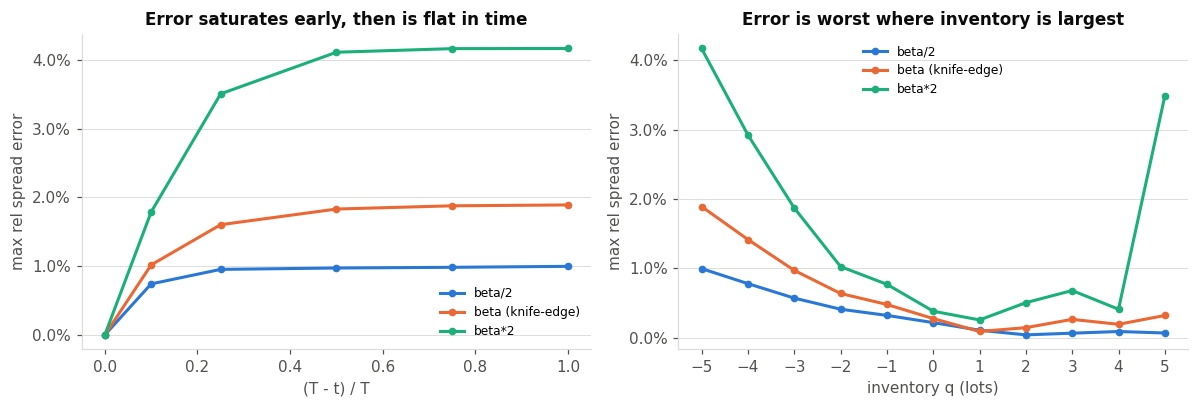

In [13]:
# Max relative spread error vs the closed form, over a whole (t, s, q) matrix.
def spread_error(sol, params, T_, grid_q=range(-5, 6)):
    worst = 0.0
    for t in (0.0, T_ / 4, T_ / 2, 3 * T_ / 4):
        for s in (0.85 * S0, 0.95 * S0, S0, 1.05 * S0, 1.15 * S0):
            for q in grid_q:
                fd = np.array(sol.spreads_at(t, s, q))
                cf = np.array(optimal_spreads(t, s, q, K, tau, T_, IV, params))
                worst = max(worst, np.abs(fd / cf - 1).max())
    return worst

zeta_minus = lambda b: np.sqrt(ups * b) - PARAMS.alpha
accuracy = pd.DataFrame([
    {'beta': BETAS[lbl], 'zeta_minus': zeta_minus(BETAS[lbl]),
     'max rel spread error': spread_error(sols[lbl], replace(PARAMS, beta=BETAS[lbl]), T)}
    for lbl in BETAS
], index=list(BETAS)).rename_axis('case')
display(accuracy.style.format({'beta': '{:,.0f}', 'zeta_minus': '{:+.3f}',
                               'max rel spread error': '{:.3%}'}))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
fracs = np.array([0.0, 0.1, 0.25, 0.5, 0.75, 1.0])
for color, lbl in zip(SERIES, BETAS):
    p_b = replace(PARAMS, beta=BETAS[lbl])
    axes[0].plot(fracs, [max(np.abs(np.array(sols[lbl].spreads_at(T * (1 - f), S0, q))
                                    / np.array(optimal_spreads(T * (1 - f), S0, q, K, tau, T, IV, p_b)) - 1).max()
                             for q in range(-5, 6)) for f in fracs],
                 color=color, marker='o', ms=4, label=lbl)
    axes[1].plot(range(-5, 6), [np.abs(np.array(sols[lbl].spreads_at(0.0, S0, q))
                                       / np.array(optimal_spreads(0.0, S0, q, K, tau, T, IV, p_b)) - 1).max()
                                for q in range(-5, 6)],
                 color=color, marker='o', ms=4, label=lbl)

axes[0].set_title('Error saturates early, then is flat in time')
axes[0].set_xlabel('(T - t) / T'); axes[0].set_ylabel('max rel spread error')
axes[1].set_title('Error is worst where inventory is largest')
axes[1].set_xlabel('inventory q (lots)'); axes[1].set_ylabel('max rel spread error')
axes[1].set_xticks(range(-5, 6))
for ax in axes:
    ax.yaxis.set_major_formatter(lambda v, _: f'{v:.1%}')
    ax.legend(fontsize=8); ax.grid(axis='y'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**The knife-edge was the wrong thing to worry about.** Accuracy degrades *monotonically in* $\beta$:
halving it makes the approximation **more** accurate than at the knife-edge, doubling it makes it
**less**. Proximity to $\zeta_-=0$ is not the variable — $\beta$ is, because $\beta$ sets
$|\psi_2|$, which sets how far $z = \kappa(\delta - 1/\kappa)$ strays from zero, and $z$ is the
argument the exponential is expanded about. The same mechanism explains the right-hand panel: error
grows with $|q|$, since the inventory skew is what pushes $\delta$ away from $1/\kappa$.

The left panel adds a second correction to §7's theme: the error saturates by
$(T-t)/T \approx 0.25$ and is flat thereafter. The paper's "very satisfactory performance over a
short market-making horizon" is true, but **the horizon is not what makes it true** — the error is a
function of state, not of elapsed time.

So: at $\beta \times 2$ the spreads are wrong by up to several percent. Does it matter?

In [14]:
# Simulate the EXACT policy read off the PDE grid, against the closed form, on identical
# paired paths -- the only way to price the approximation in objective terms.
# 8000 paths, matching the standalone report. At 3000 the confidence interval
# (~17) is wider than the effect being measured, which produces marginally
# 'significant' gaps that are pure noise.
N9 = 8000
cost = []
for lbl, b in BETAS.items():
    p_b = replace(PARAMS, beta=b)
    shared = dict(S0=S0, n_steps=400, n_paths=N9, seed=1)
    exact = simulate(surface, K, tau, T, p_b, spread_fn=sols[lbl].spreads_batch, **shared)
    approx = simulate(surface, K, tau, T, p_b, **shared)
    assert np.abs(exact.q).max() < PDE_GRID['q_max'], 'simulation left the PDE grid'
    gap = objective(exact, p_b) - objective(approx, p_b)
    cost.append({'case': lbl,
                 'exact (PDE policy)': objective(exact, p_b).mean(),
                 'closed form': objective(approx, p_b).mean(),
                 'gap': gap.mean(),
                 '95% CI': 1.96 * gap.std() / np.sqrt(N9),
                 'gap as % of objective': abs(gap.mean()) / objective(exact, p_b).mean()})

cost = pd.DataFrame(cost).set_index('case')
assert cost['gap as % of objective'].max() < 0.01, 'approximation cost exceeded 1% of the objective'
display(cost.style.format({'exact (PDE policy)': '{:,.1f}', 'closed form': '{:,.1f}',
                           'gap': '{:+.2f}', '95% CI': '{:.2f}',
                           'gap as % of objective': '{:.3%}'}))

,exact (PDE policy),closed form,gap,95% CI,gap as % of objective
case,,,,,
beta/2,"1,406.2","1,402.8",+3.39,10.27,0.241%
beta (knife-edge),"1,386.0","1,375.2",+10.84,10.08,0.782%
beta*2,"1,348.8","1,348.1",+0.68,10.27,0.050%


**Fifth finding — and it retires the caveat this notebook has been carrying.** At every $\beta$, on
and off the knife-edge, the closed-form rule gives up **well under 1% of the objective** against the
exact policy — including at $\beta \times 2$, where the spreads themselves are several percent wrong.
The gaps are of the same order as their own confidence intervals, so the honest reading is "too small
to measure cleanly at this sample size," not "exactly zero": the exact policy is optimal by
construction, so the true gap is non-negative, just economically negligible.

That gap between a several-percent error in the **control** and a near-zero error in the **value** is
the envelope theorem, not luck. The objective is stationary at its optimum, so a first-order error in
the quote costs only second order in eq. 2. Practically: **do not size a tolerance on spread accuracy
— it overstates the damage by an order of magnitude.**

It also settles the open question from §6. Finding 3 — the closed-form rule beating fixed-width
quoting on eq. 2 — was measured at the knife-edge, but it holds either side of it, and the
approximation was never what was in question.

The full write-up, including the grid-stability constraints and the scheme's derivation, is in
[`notes/pde_validation_report.html`](../notes/pde_validation_report.html).